<a href="https://colab.research.google.com/github/annmaria-roy/ML-LAB/blob/main/EXP3_Ridge_lasso_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score


In [8]:
diabetes=load_diabetes()
X=diabetes.data
y=diabetes.target

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

print("Trainig samples:",x_train.shape[0])
print("Testing samples:",x_test.shape[0])

Trainig samples: 353
Testing samples: 89


In [10]:
linear_model=LogisticRegression()
linear_model.fit(x_train_scaled,y_train)
y_pred_linear=linear_model.predict(x_test_scaled)

print("linear regression")
print("mean square error:",mean_squared_error(y_test,y_pred_linear))
print("r2 score:",r2_score(y_test,y_pred_linear))

linear regression
mean square error: 3348.8314606741574
r2 score: 0.367924585849815


In [16]:
ridge=Ridge()
param_grid={'alpha':[0.01,1,10,100]}
ridge_cv=GridSearchCV(ridge,param_grid,cv=5)
ridge_cv.fit(x_train_scaled,y_train)

best_ridge=ridge_cv.best_estimator_
y_pred_ridge=best_ridge.predict(x_test_scaled)

print("best Alpha for Ridge:",ridge_cv.best_params_['alpha'])
print("MSE:",mean_squared_error(y_test,y_pred_ridge))
print("R-squared:",r2_score(y_test,y_pred_ridge))


best Alpha for Ridge: 10
MSE: 2875.7787184218428
R-squared: 0.4572109567780849


In [19]:
lasso=Lasso(max_iter=10000)
lasso_cv=GridSearchCV(lasso,param_grid,cv=5)
lasso_cv.fit(x_train_scaled,y_train)

best_lasso=lasso_cv.best_estimator_
y_pred_lasso=best_lasso.predict(x_test_scaled)

print("best Alpha for Lasso:",lasso_cv.best_params_['alpha'])
print("MSE:",mean_squared_error(y_test,y_pred_lasso))
print("R-squared:",r2_score(y_test,y_pred_lasso))

best Alpha for Lasso: 1
MSE: 2824.568094049959
R-squared: 0.46687670944102466


In [22]:
results=pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression","Lasso Regression"],
    "MSE":[mean_squared_error(y_test,y_pred_linear),
           mean_squared_error(y_test,y_pred_ridge),
           mean_squared_error(y_test,y_pred_lasso)],
    'R2 Score':[r2_score(y_test,y_pred_linear),
                r2_score(y_test,y_pred_ridge),
                r2_score(y_test,y_pred_lasso)]
})

print(results)


               Model          MSE  R2 Score
0  Linear Regression  3348.831461  0.367925
1   Ridge Regression  2875.778718  0.457211
2   Lasso Regression  2824.568094  0.466877


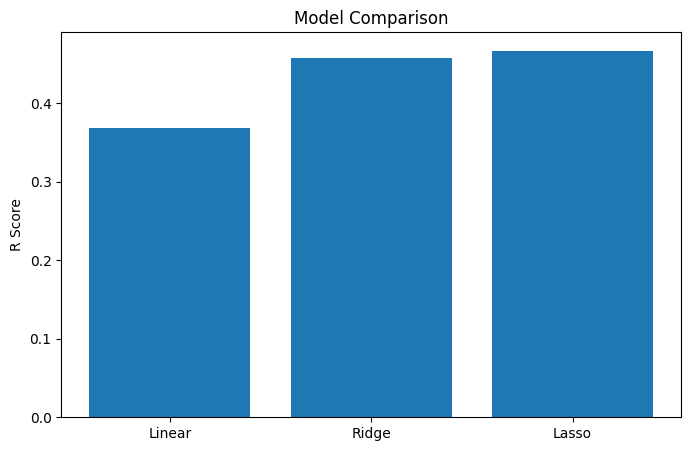

In [23]:
plt.figure(figsize=(8,5))

models=['Linear','Ridge','Lasso']
r2_scores=[r2_score(y_test,y_pred_linear),
           r2_score(y_test,y_pred_ridge),
           r2_score(y_test,y_pred_lasso)]
plt.bar(models,r2_scores)
plt.ylabel('R Score')
plt.title('Model Comparison')
plt.show()